In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('/content/employees_cleaned.csv')
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17415 entries, 0 to 17414
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17415 non-null  int64  
 1   department             17415 non-null  object 
 2   region                 17415 non-null  object 
 3   education              16644 non-null  object 
 4   gender                 17415 non-null  object 
 5   recruitment_channel    17415 non-null  object 
 6   no_of_trainings        17415 non-null  int64  
 7   age                    17415 non-null  int64  
 8   previous_year_rating   16052 non-null  float64
 9   length_of_service      17415 non-null  int64  
 10  KPIs_met_more_than_80  17415 non-null  int64  
 11  awards_won             17415 non-null  int64  
 12  avg_training_score     17415 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [5]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,771
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1363
length_of_service,0


In [6]:
#Xử lý null
df['previous_year_rating'] = df['previous_year_rating'].fillna(
    df['previous_year_rating'].median()
)

In [7]:
df['previous_year_rating'].isnull().sum()

np.int64(0)

In [8]:
#xử lý null
df['education'] = df['education'].fillna('Unknown')

In [9]:
df['education'].isnull().sum()

np.int64(0)

In [10]:
#check duplicated
df.duplicated().sum()

np.int64(0)

In [10]:
#Overview
#Tổng số nhân viên
total_emp = df['employee_id'].nunique()
print("Total Employees:", total_emp)

Total Employees: 17414


gender
m    12312
f     5103
Name: count, dtype: int64


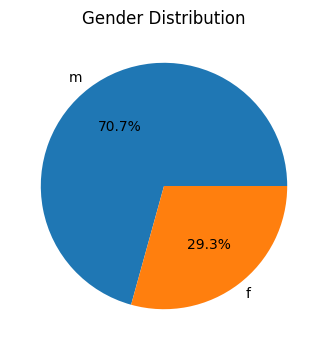

In [11]:
#Phân bố Gender
gender_dist = df['gender'].value_counts()
print(gender_dist)
plt.figure(figsize=(7,4))

plt.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

age_group
20-30    5746
30-40    8223
40-50    2474
50-60     930
Name: count, dtype: int64


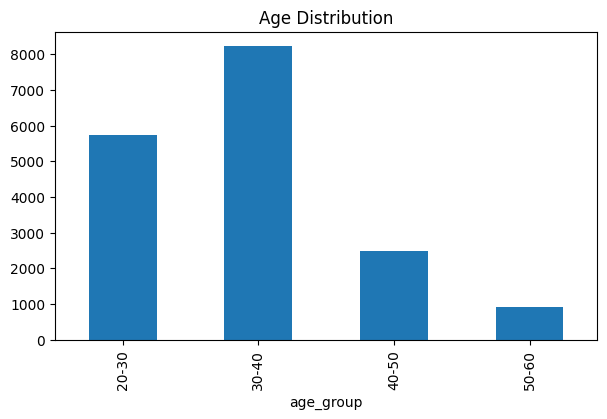

In [12]:
# Phân bố nhóm tuổi
df['age_group'] = pd.cut(
    df['age'],
    bins=[20,30,40,50,60],
    labels=['20-30','30-40','40-50','50-60']
)

age_dist = df['age_group'].value_counts().sort_index()
print(age_dist)
plt.figure(figsize=(7,4))
age_dist.plot(kind='bar')
plt.title('Age Distribution')
plt.show()

education
Bachelors          11517
Masters & above     4841
Unknown              771
Below Secondary      286
Name: count, dtype: int64


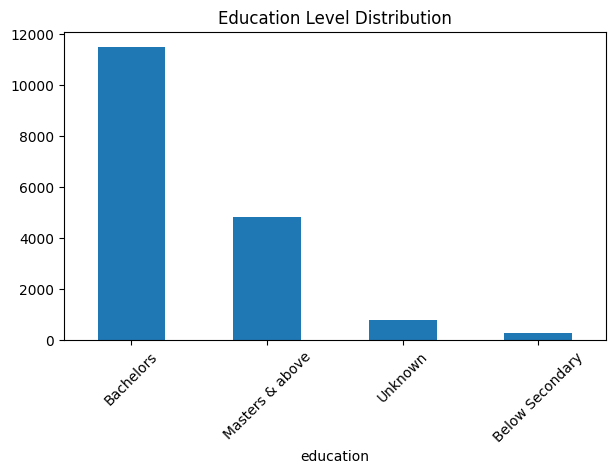

In [13]:
#Phân bố học vấn
edu_dist = df['education'].value_counts()
print(edu_dist)
plt.figure(figsize=(7,4))
edu_dist.plot(kind='bar')
plt.title('Education Level Distribution')
plt.xticks(rotation=45)
plt.show()

OVER VIEWS

In [14]:
df['KPIs_met_more_than_80'].value_counts(normalize=True)

,proportion
KPIs_met_more_than_80,
0,0.641114
1,0.358886


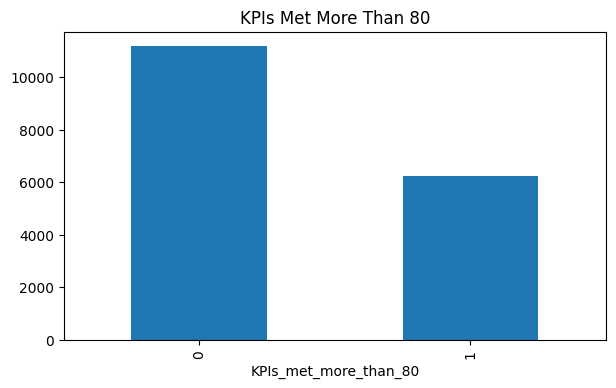

In [ ]:
plt.figure(figsize=(7,4))
df['KPIs_met_more_than_80'].value_counts().plot(kind='bar')
plt.title('KPIs Met More Than 80')
plt.show()

Phần lớn nhân viên không đạt KPI (>80%), chiếm khoảng 64%, trong khi chỉ có khoảng 36% đạt KPI.

=> Hiệu suất tổng thể của công ty chưa cao. Bộ dữ liệu cho thấy sự mất cân bằng ở mức độ vừa phải trong DN, với số lượng nhân viên không đạt được mục tiêu KPI nhiều hơn đáng kể so với những người đạt được. Điều này có thể :

KPI đang đặt quá cao
hoặc nhân viên chưa được hỗ trợ đủ (training, resource, etc.)

==> Cần tìm hiểu các yếu tố ảnh hưởng đến KPI để cải thiện hiệu suất làm việc của nhân viên

**EDA**

1. Overall Performance

In [15]:
#% nhân viên đạt KPI
kpi_rate = df['KPIs_met_more_than_80'].mean()
print(f"% nhân viên đạt KPI: {kpi_rate*100:.2f}%")

% nhân viên đạt KPI: 35.89%


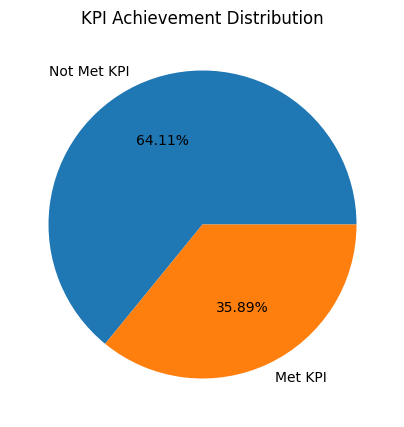

In [16]:
kpi_rate = df['KPIs_met_more_than_80'].mean()


labels = ['Not Met KPI', 'Met KPI']
sizes = [1 - kpi_rate, kpi_rate]


plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title("KPI Achievement Distribution")
plt.show()

In [17]:
#% nhân viên nhận thưởng
award_rate = df['awards_won'].mean()
print(f"% nhân viên nhận thưởng: {award_rate*100:.2f}%")

% nhân viên nhận thưởng: 2.34%


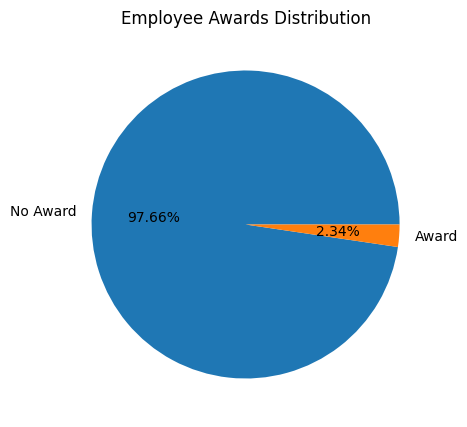

In [18]:
plt.figure(figsize=(5,5))
award_rate = df['awards_won'].mean()
labels = ['No Award', 'Award']
sizes = [1 - award_rate, award_rate]
plt.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title("Employee Awards Distribution")
plt.show()

Mặc dù ~36% đạt KPI nhưng chỉ có ~2% nhận được giải thưởng → tiêu chuẩn nhận thưởng khá cao”

2. KPI theo Nhân khẩu học

In [19]:
#KPI theo Gender
kpi_gender = df.groupby('gender')['KPIs_met_more_than_80'].mean().reset_index()
kpi_gender

,gender,KPIs_met_more_than_80
0,f,0.389183
1,m,0.346329


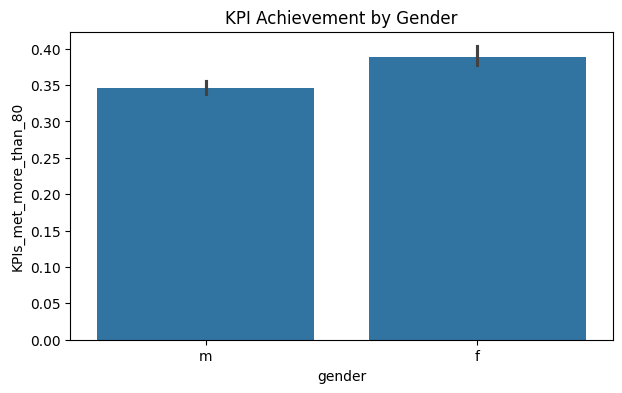

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='gender', y='KPIs_met_more_than_80', data=df)
plt.title('KPI Achievement by Gender')
plt.show()

Female (f): ~38.9%
Male (m): ~34.6%

-> Nhân viên nữ có tỷ lệ đạt KPI cao hơn nam (~4%), tuy nhiên sự khác biệt không quá lớn.

=> Gender không phải yếu tố quyết định mạnh

In [20]:
#KPI theo Age Group
kpi_age = df.groupby('age_group')['KPIs_met_more_than_80'].mean().reset_index()
kpi_age

/tmp/ipykernel_2535/2371380145.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kpi_age = df.groupby('age_group')['KPIs_met_more_than_80'].mean().reset_index()


,age_group,KPIs_met_more_than_80
0,20-30,0.364601
1,30-40,0.368357
2,40-50,0.331447
3,50-60,0.317204


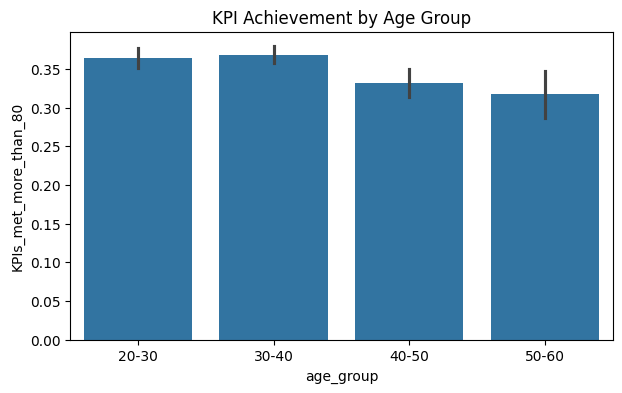

In [21]:
plt.figure(figsize=(7,4))
sns.barplot(x='age_group', y='KPIs_met_more_than_80', data=df)
plt.title('KPI Achievement by Age Group')
plt.show()

20–30: 36.5%

30–40: 36.8% (cao nhất)

40–50: 33.1%

50–60: 31.7% (thấp nhất)

-> Hiệu suất đạt KPI cao nhất ở nhóm tuổi 30–40 và giảm dần ở các nhóm tuổi lớn hơn.

=> Hiệu suất của nhân viên dường như đạt đỉnh ở giai đoạn giữa sự nghiệp và giảm nhẹ theo độ tuổi.

In [ ]:
#KPI theo Education
kpi_edu = df.groupby('education')['KPIs_met_more_than_80'].mean().reset_index()
kpi_edu

,education,KPIs_met_more_than_80
0,Bachelors,0.357993
1,Below Secondary,0.465035
2,Masters & above,0.368312
3,Unknown,0.273671


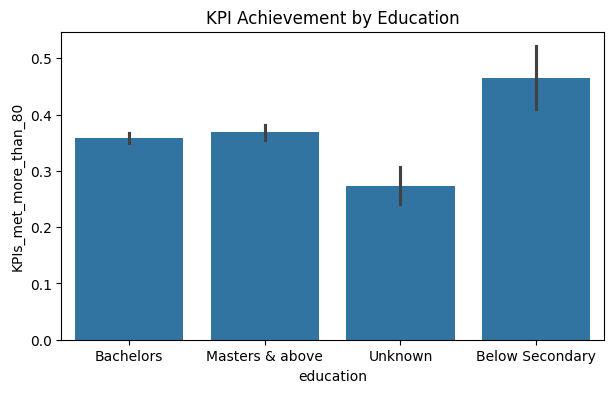

In [22]:
plt.figure(figsize=(7,4))
sns.barplot(x='education', y='KPIs_met_more_than_80', data=df)
plt.title('KPI Achievement by Education')
plt.show()

Below Secondary: 46.5% (cao nhất) -> khả năng cao: Họ làm ở: Role đơn giản hơn có KPI dễ đạt hơn

Masters & above: 36.8%

Bachelors: 35.8%

Unknown: 27.4% (thấp nhất)

Trình độ học vấn cao hơn không nhất thiết dẫn đến KPI tốt hơn.

3. Work-related Analysis - KPI

In [23]:
#KPI theo Department
kpi_dept = df.groupby('department')['KPIs_met_more_than_80'].mean().reset_index()
kpi_dept = kpi_dept.sort_values(by='KPIs_met_more_than_80', ascending=False)
kpi_dept


,department,KPIs_met_more_than_80
6,R&D,0.448795
4,Operations,0.440692
0,Analytics,0.400118
1,Finance,0.397756
5,Procurement,0.373214
2,HR,0.361011
8,Technology,0.356071
3,Legal,0.355422
7,Sales & Marketing,0.277208


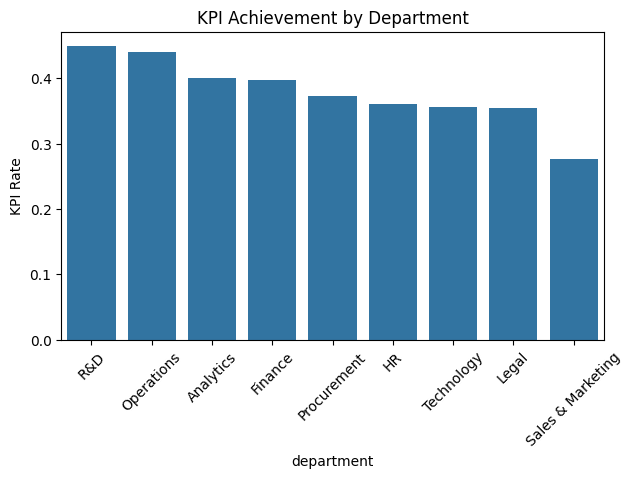

In [24]:
plt.figure(figsize=(7,4))
sns.barplot(x='department', y='KPIs_met_more_than_80', data=kpi_dept)
plt.xticks(rotation=45)
plt.title("KPI Achievement by Department")
plt.ylabel("KPI Rate")
plt.show()

Cao nhất:R&D (khoảng 44.9%),  Operations (khoảng 44.1%), Analytics (40.0%)

Thấp nhất: Sales & Marketing (~27.7%)

-> Có sự khác biệt rõ rệt giữa các phòng ban, với R&D và Operations có hiệu suất cao nhất, trong khi Sales & Marketing thấp đáng kể.
Điều này có thể do:
- R&D / Ops:KPI có thể rõ ràng, đo lường dễ, công việc ổn định

- Sales & Marketing: KPI khó hơn (target cao, biến động), phụ thuộc thị trường

In [25]:
#KPI theo Region
kpi_region = df.groupby('region')['KPIs_met_more_than_80'].mean().reset_index()
kpi_region = kpi_region.sort_values(by='KPIs_met_more_than_80', ascending=False)
kpi_region.head()

,region,KPIs_met_more_than_80
28,region_4,0.476357
22,region_3,0.445455
14,region_22,0.411558
8,region_17,0.399254
20,region_28,0.397674


Text(0.5, 1.0, 'KPI Achievement by Region')

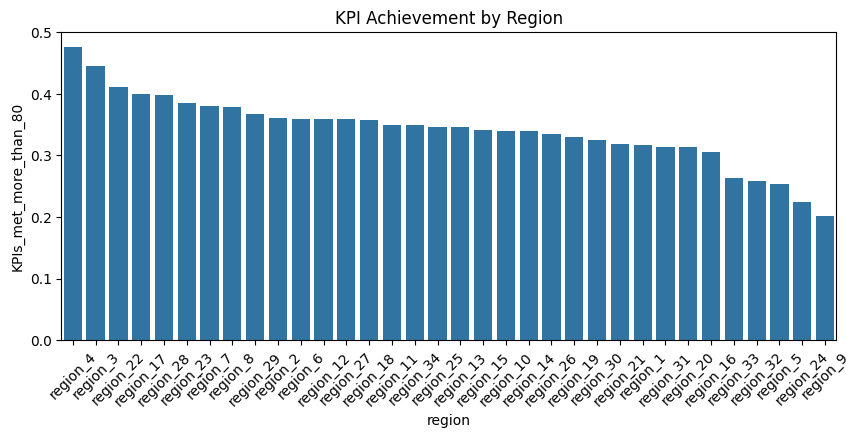

In [26]:
plt.figure(figsize=(10,4))
sns.barplot(x='region', y='KPIs_met_more_than_80', data=kpi_region)
plt.xticks(rotation=45)
plt.title("KPI Achievement by Region")

Dao động từ khoảng: ~20% → ~48%
-> Có sự chênh lệch giữa các region.

KPI có sự khác biệt giữa các khu vực, tuy nhiên phân bố khá liên tục và không có sự phân tách quá rõ ràng.

In [27]:
#KPI theo Length of Service
df['service_group'] = pd.cut(df['length_of_service'],
                            bins=[0,5,10,15,20,25,30],
                            labels=['0-5','5-10','10-15','15-20','20-25','25+'])

kpi_service = df.groupby('service_group')['KPIs_met_more_than_80'].mean().reset_index()
kpi_service

/tmp/ipykernel_2535/3026593323.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kpi_service = df.groupby('service_group')['KPIs_met_more_than_80'].mean().reset_index()


,service_group,KPIs_met_more_than_80
0,0-5,0.382777
1,5-10,0.349184
2,10-15,0.258573
3,15-20,0.271012
4,20-25,0.179775
5,25+,0.238095


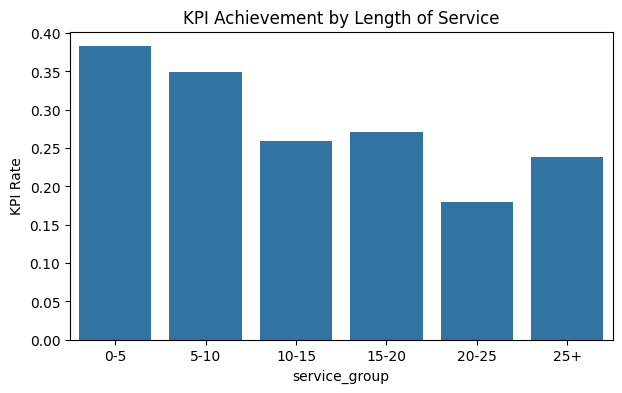

In [28]:
plt.figure(figsize=(7,4))
sns.barplot(x='service_group', y='KPIs_met_more_than_80', data=kpi_service)
plt.title("KPI Achievement by Length of Service")
plt.ylabel("KPI Rate")
plt.show()

KPI giảm dần theo thâm niên, đặc biệt thấp ở nhóm nhân viên làm việc lâu năm.

0–5 năm: 38.3% (cao nhất)

20–25 năm: 17.9% (thấp nhất)


==> Hiệu suất bị ảnh hưởng mạnh mẽ bởi vai trò công việc (bộ phận làm việc) và có xu hướng giảm dần theo số năm làm việc, cho thấy cần có các biện pháp can thiệp có mục tiêu đối với các bộ phận cụ thể và nhân viên lâu năm

4. Training Impact - KPI

In [29]:
#no_of_trainings vs KPI
train_kpi = df.groupby('no_of_trainings')['KPIs_met_more_than_80'].mean().reset_index()
train_kpi

,no_of_trainings,KPIs_met_more_than_80
0,1,0.367736
1,2,0.333333
2,3,0.306122
3,4,0.204380
4,5,0.307692
5,6,0.000000
6,7,0.166667
7,8,0.500000
8,9,0.500000


1 training → 36.8% (cao)

2 → 33.3%

3 → 30.6%

4 → 20.4% (giảm mạnh)

5 → 30.7% (hồi nhẹ)

6 → 0% -> Không đáng tin hoàn toàn vì có thể sample size nhỏ (ít người)

7 → 16.7%

8, 9 → 50% (rất cao) -> Không đáng tin hoàn toàn vì có thể sample size nhỏ (ít người)

Tỷ lệ đạt KPI có xu hướng giảm khi số lượng training tăng từ 1 đến 4, cho thấy việc tham gia quá nhiều khóa đào tạo có thể ảnh hưởng tiêu cực đến hiệu suất làm việc. (Training nhiều ≠ hiệu suất cao)

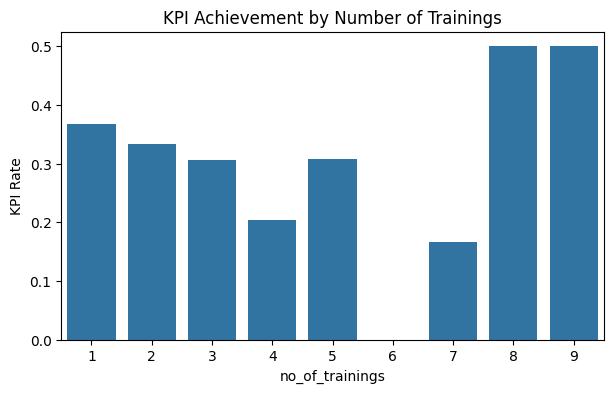

In [30]:
plt.figure(figsize=(7,4))
sns.barplot(x='no_of_trainings', y='KPIs_met_more_than_80', data=train_kpi)
plt.title("KPI Achievement by Number of Trainings")
plt.ylabel("KPI Rate")
plt.show()

In [31]:
#avg_training_score vs KPI
kpi_training_score = df.groupby('avg_training_score')['KPIs_met_more_than_80'].mean().reset_index()
kpi_training_score.head()

,avg_training_score,KPIs_met_more_than_80
0,39,0.000000
1,40,0.000000
2,41,0.285714
3,42,0.166667
4,43,0.304348


Score thấp (39–40) → KPI = 0%

Score tăng → KPI bắt đầu tăng (~28–30%)

Nhân viên có điểm đào tạo cao hơn có xu hướng đạt KPI tốt hơn, cho thấy chất lượng đào tạo có ảnh hưởng tích cực đến hiệu suất.

Text(0.5, 1.0, 'KPI Achievement by Average Training Score')

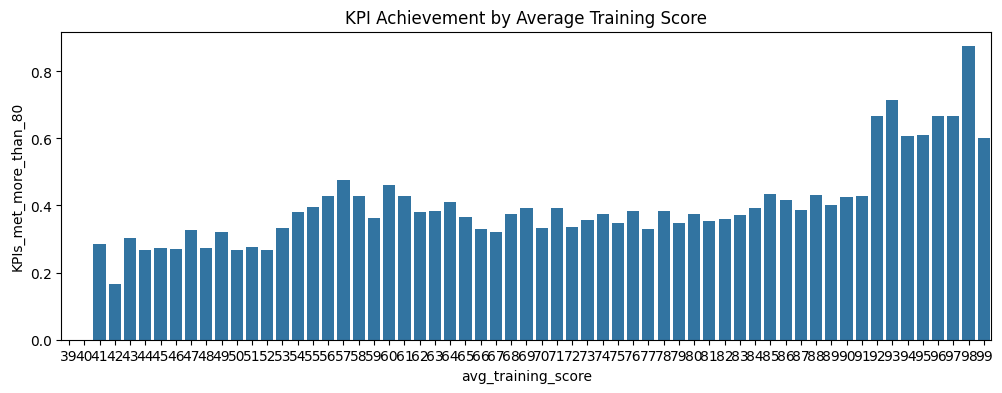

In [32]:
plt.figure(figsize=(12,4))
sns.barplot(x='avg_training_score', y='KPIs_met_more_than_80', data=kpi_training_score)
plt.title("KPI Achievement by Average Training Score")

==> Mặc dù việc tăng số lượng đào tạo không cải thiện hiệu suất và thậm chí có thể làm giảm hiệu suất, nhưng hiệu quả đào tạo (số điểm đào tạo của nhân viên) cao hơn có liên quan tích cực đến việc đạt được KPI.

5. Historical Performance – KPI

In [33]:
#previous_year_rating vs KPI
kpi_rating = df.groupby('previous_year_rating')['KPIs_met_more_than_80'].mean().reset_index()
kpi_rating

,previous_year_rating,KPIs_met_more_than_80
0,1.0,0.133232
1,2.0,0.189628
2,3.0,0.284420
3,4.0,0.406844
4,5.0,0.633220


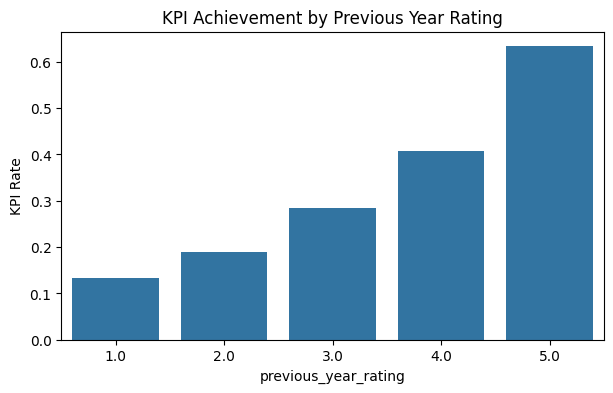

In [34]:
plt.figure(figsize=(7,4))
sns.barplot(x='previous_year_rating', y='KPIs_met_more_than_80', data=kpi_rating)
plt.title("KPI Achievement by Previous Year Rating")
plt.ylabel("KPI Rate")
plt.show()

Tỷ lệ đạt KPI tăng mạnh theo đánh giá năm trước, từ 13% (rating 1) lên đến hơn 63% (rating 5).

-> Có mối quan hệ rõ ràng giữa performance quá khứ và hiện tại: Xếp hạng năm trước là yếu tố dự báo mạnh nhất về thành tích KPI, cho thấy xu hướng tăng rõ ràng và nhất quán.

6. Recruitment Effectiveness – KPI

In [35]:
#KPI theo Recruitment Channel
kpi_recruit = df.groupby('recruitment_channel')['KPIs_met_more_than_80'].mean().reset_index()
kpi_recruit

,recruitment_channel,KPIs_met_more_than_80
0,other,0.353882
1,referred,0.533123
2,sourcing,0.358008


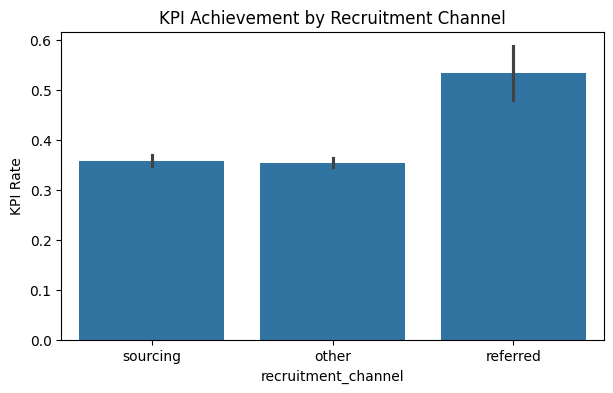

In [36]:
plt.figure(figsize=(7,4))
sns.barplot(x='recruitment_channel', y='KPIs_met_more_than_80', data=df)
plt.title("KPI Achievement by Recruitment Channel")
plt.ylabel("KPI Rate")
plt.show()

Nhân viên được tuyển qua kênh referral (giới thiệu) có tỷ lệ đạt KPI cao vượt trội (khoang 53%), cao hơn đáng kể so với các kênh khác (~35%).

-> Nhân viên được giới thiệu sẽ có nhiều ưu điểm:

- Fit văn hóa tốt hơn

- Có network nội bộ

- Được “lọc trước”

=> Giới thiệu là kênh tuyển dụng hiệu quả nhất, đạt KPI cao hơn đáng kể so với các kênh khác.

7. Kiểm định thống kê

In [37]:
#Chi-square test (Categorical variables). KPI là biến binary
# Dùng cho: department, education, recruitment_channel
from scipy.stats import chi2_contingency
cols = ['department', 'education', 'recruitment_channel']

for col in cols:
    table = pd.crosstab(df[col], df['KPIs_met_more_than_80'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{col}: p-value = {p}")

department: p-value = 1.764740276812837e-58
education: p-value = 9.438420079942154e-09
recruitment_channel: p-value = 4.806881533876245e-10


Department có p-value cực nhỏ (~10⁻⁵⁸), cho thấy đây là yếu tố có ảnh hưởng rất mạnh đến KPI.

Recruitment channel cũng có ảnh hưởng đáng kể đến KPI (p < 0.001), đặc biệt là nhóm referral có hiệu suất vượt trội.

Education

Education có ý nghĩa thống kê, nhưng mức độ ảnh hưởng thấp hơn so với department và recruitment channel.

=> Tất cả các biến phân loại được kiểm tra đều có mối quan hệ có ý nghĩa thống kê với thành tích KPI, trong đó bộ phận là yếu tố có ảnh hưởng nhất.

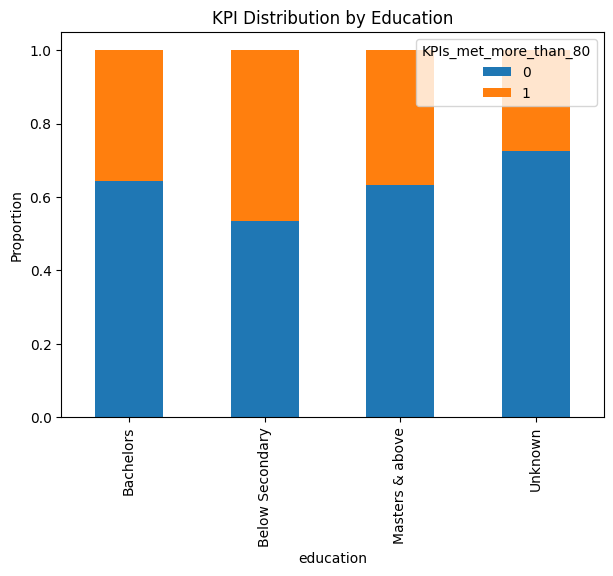

In [40]:
#Education
edu_norm = pd.crosstab(df['education'], df['KPIs_met_more_than_80'], normalize='index')

edu_norm.plot(kind='bar', stacked=True, figsize=(7,5))
plt.title("KPI Distribution by Education")
plt.ylabel("Proportion")
plt.show()

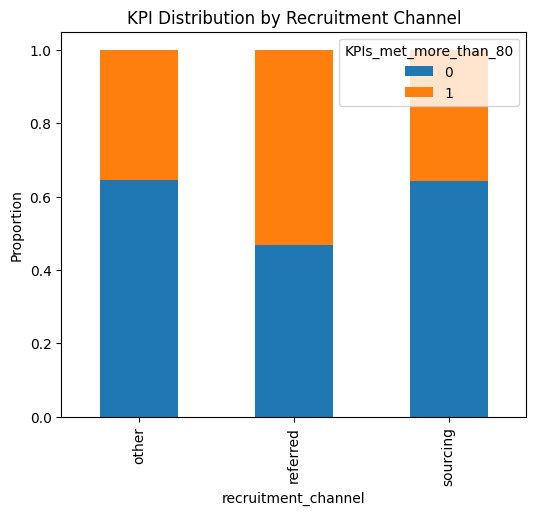

In [41]:
#Recruitment
rec_norm = pd.crosstab(df['recruitment_channel'], df['KPIs_met_more_than_80'], normalize='index')

rec_norm.plot(kind='bar', stacked=True, figsize=(6,5))
plt.title("KPI Distribution by Recruitment Channel")
plt.ylabel("Proportion")
plt.show()

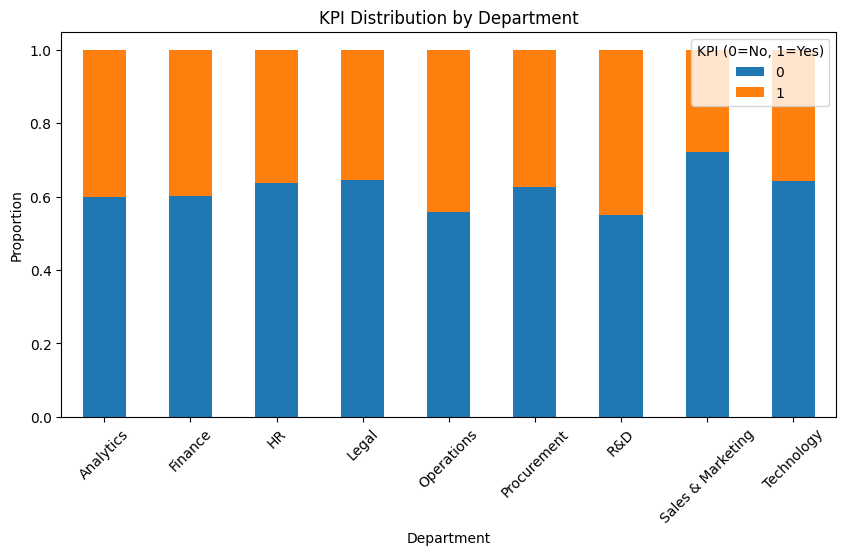

In [42]:
# department
dept_norm = pd.crosstab(df['department'], df['KPIs_met_more_than_80'], normalize='index')
dept_norm

dept_norm.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title("KPI Distribution by Department")
plt.ylabel("Proportion")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.legend(title="KPI (0=No, 1=Yes)")
plt.show()


In [44]:
#ANOVA (cho numerical)
#Dùng cho: age, length_of_service, avg_training_score, previous_year_rating
from scipy.stats import f_oneway

group1 = df[df['KPIs_met_more_than_80'] == 1]['age']
group0 = df[df['KPIs_met_more_than_80'] == 0]['age']

f_stat, p = f_oneway(group1, group0)


print("F-statistic:", f_stat)
print("p-value:", p)

F-statistic: 11.232135070561702
p-value: 0.0008056410670052085


Age
p-value: 0.0008056

p < 0.05 → có ý nghĩa thống kê

In [45]:
#lenghth of service

group_kpi_1 = df[df['KPIs_met_more_than_80'] == 1]['length_of_service']
group_kpi_0 = df[df['KPIs_met_more_than_80'] == 0]['length_of_service']

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(group_kpi_1, group_kpi_0)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 110.86341354177465
p-value: 7.580754238635559e-26


F-statistic: 110.86
p-value: ~7.58e-26

p rất nhỏ → ảnh hưởng mạnh đến KPI (KPI giảm theo thâm niên)

In [47]:
#avg_training_score
group_kpi_1 = df[df['KPIs_met_more_than_80'] == 1]['avg_training_score']
group_kpi_0 = df[df['KPIs_met_more_than_80'] == 0]['avg_training_score']

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(group_kpi_1, group_kpi_0)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 90.42299345642719
p-value: 2.1674265785604955e-21


Avg Training Score
F-statistic: 90.42

p-value ~0 <<< 0,05

-> có ý nghĩa thống kê rất mạnh (Training quality → KPI tăng)

In [48]:
#previous_year_rating
from scipy.stats import f_oneway

groups = [df[df['previous_year_rating'] == i]['KPIs_met_more_than_80'] for i in range(1,6)]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 580.9416675172037
p-value: 0.0


Previous Year Rating: p-value ≈ 0: Có sự khác biệt cực kỳ có ý nghĩa thống kê giữa các nhóm rating

F-stat rất lớn-> Mức độ ảnh hưởng rất mạnh

=> Xếp hạng năm trước có tác động rất đáng kể đến thành tích KPI, với mức độ ảnh hưởng rất mạnh.

==> Kiểm định ANOVA chỉ ra rằng tất cả các biến số được kiểm tra đều ảnh hưởng đáng kể đến việc đạt được KPI. Trong số đó, đánh giá năm trước, thời gian làm việc và điểm đào tạo trung bình có tác động mạnh nhất, trong khi tuổi tác có tác động tương đối yếu hơn.

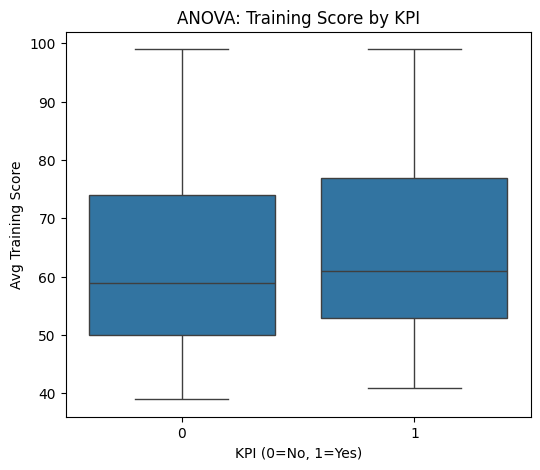

In [49]:
#Avg Training Score

plt.figure(figsize=(6,5))
sns.boxplot(x='KPIs_met_more_than_80', y='avg_training_score', data=df)
plt.title("ANOVA: Training Score by KPI")
plt.xlabel("KPI (0=No, 1=Yes)")
plt.ylabel("Avg Training Score")
plt.show()

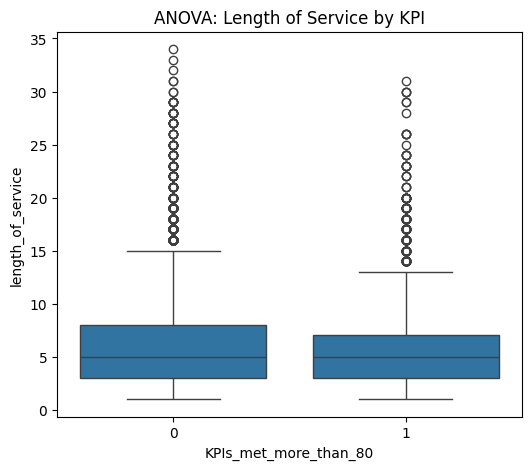

In [50]:
#Length of Service
plt.figure(figsize=(6,5))
sns.boxplot(x='KPIs_met_more_than_80', y='length_of_service', data=df)
plt.title("ANOVA: Length of Service by KPI")
plt.show()

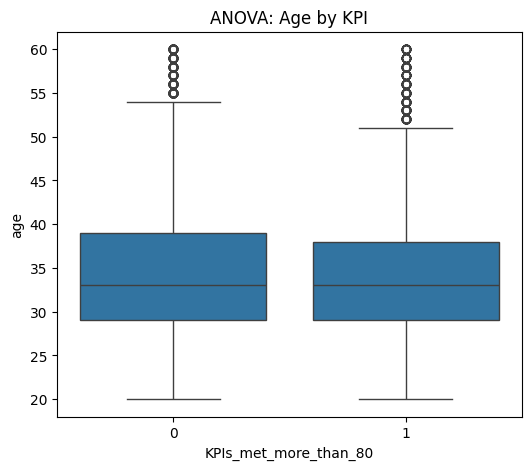

In [51]:
#Age
plt.figure(figsize=(6,5))
sns.boxplot(x='KPIs_met_more_than_80', y='age', data=df)
plt.title("ANOVA: Age by KPI")
plt.show()

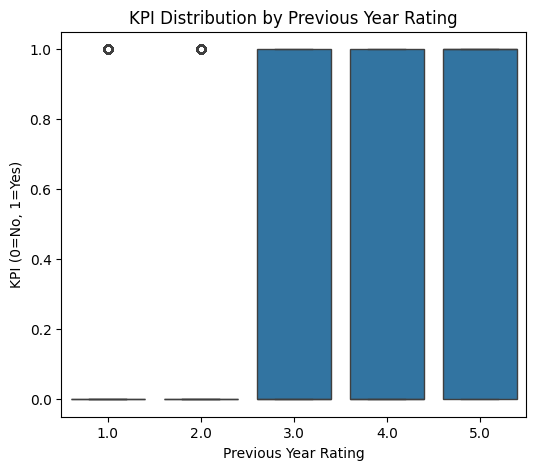

In [52]:
plt.figure(figsize=(6,5))
sns.boxplot(x='previous_year_rating', y='KPIs_met_more_than_80', data=df)

plt.title("KPI Distribution by Previous Year Rating")
plt.xlabel("Previous Year Rating")
plt.ylabel("KPI (0=No, 1=Yes)")
plt.show()

Conclusions: Phân tích này khám phá các yếu tố ảnh hưởng đến hiệu suất của nhân viên, được đo bằng thành tích KPI (>80%). Các phát hiện cho thấy hiệu suất được thúc đẩy nhiều hơn bởi các yếu tố nội bộ và liên quan đến công việc hơn là đặc điểm nhân khẩu học.

1. Xếp hạng năm trước – Dự đoán mạnh nhất
Thành tích KPI tăng đáng kể từ 13% (xếp hạng 1) lên 63% (xếp hạng 5). Cho biết tính nhất quán hiệu suất mạnh mẽ theo thời gian. Những nhân viên đã thể hiện tốt trong quá khứ có nhiều khả năng sẽ tiếp tục thể hiện tốt.

2. Phòng/ BP làm việc – Nơi điều khiển hiệu suất chính. Sự khác biệt đáng kể giữa các phòng ban
R&D và Vận hành hoạt động tốt nhất (44%), Bán hàng & Tiếp thị hoạt động kém nhất (28%). Vai trò công việc và tính chất công việc tác động mạnh mẽ đến việc đạt được KPI.

3. Đào tạo – Chất lượng hơn số lượng
Tăng số lượng đào tạo không cải thiện hiệu suất
Trong một số trường hợp, đào tạo quá nhiều sẽ làm giảm thành tích KPI. Tuy nhiên, điểm tập luyện cao hơn → hiệu suất tốt hơn.

4. Kinh nghiệm (Thời gian làm việc)
Thành tích KPI giảm dần theo số năm làm việc.
Nhân viên mới làm việc tốt hơn nhân viên lâu năm

-> Có thể bị kiệt sức hoặc giảm động lực theo thời gian.

5. Kênh tuyển dụng
Những người được giới thiệu thuê hoạt động tốt nhất (53%). Các kênh khác hiển thị tương tự nhưng hiệu suất thấp hơn (35%)

-> Giới thiệu là phương pháp tuyển dụng hiệu quả nhất.

6. Yếu tố nhân khẩu học
Giới tính, trình độ đào tạo và khu vực cho thấy tác động hạn chế. Tuổi cho thấy tác dụng nhẹ (đỉnh điểm ở 30–40) -> Hiệu suất không được quyết định mạnh mẽ bởi yếu tố nhân khẩu học.

Hiệu suất của nhân viên chủ yếu được thúc đẩy bởi hiệu suất trong quá khứ, vai trò công việc và hiệu quả đào tạo, trong khi các yếu tố nhân khẩu học đóng vai trò tối thiểu. Các tổ chức nên tập trung vào việc tối ưu hóa các quy trình nội bộ và chiến lược quản lý nhân tài để cải thiện hiệu suất tổng thể.

Recomendations:
1. Tập trung vào những người có thành tích cao
Sử dụng xếp hạng năm trước để: Xác định tài năng hàng đầu và ưu tiên các quyết định thăng tiến

2. Cải thiện chiến lược đào tạo
- Giảm tải đào tạo quá mức
- Tập trung vào: Chất lượng đào tạo và phát triển kỹ năng thực hành

3. Nhắm mục tiêu vào các Phòng ban có hiệu suất thấp
- Điều tra Bán hàng & Tiếp thị
- Cải thiện: Cấu trúc KPI, tăng hỗ trợ và nguồn lực

4. Hiệu suất chỉ suy giảm theo thời gian làm việc, do đó cần:
- Phát triển các chương trình duy trì và tạo động lực
- Tái cơ cấu vị trí tuyển dụng cho các độ tuổi đạt KPI cao

5. Mở rộng tuyển dụng người giới thiệu
- Khuyến khích các chương trình giới thiệu nhân viên
- Tận dụng mạng lưới nội bộ để cải thiện chất lượng tuyển dụng

In [27]:
#Top 5 yeu to anh huong den KPI
from sklearn.linear_model import LogisticRegression

results = []
drop_cols = ['KPIs_met_more_than_80', 'awards_won']

for col in df.columns:
    if col in drop_cols:
        continue
    X = df[[col]].copy()
    y = df['KPIs_met_more_than_80']

    # Encode categorical
    if X[col].dtype == 'object':
        X = pd.get_dummies(X, drop_first=True)

    try:
        model = LogisticRegression(max_iter=1000)
        model.fit(X, y)

        coef = model.coef_[0]

        # lấy mean coef (giữ dấu)
        coef_mean = coef.mean()

        # lấy độ mạnh (abs)
        importance = abs(coef_mean)

        results.append((col, coef_mean, importance))

    except:
        continue

# DataFrame
results_df = pd.DataFrame(results, columns=['feature', 'coef', 'importance'])

# Sort theo độ mạnh
results_df = results_df.sort_values(by='importance', ascending=False)

# Top 5
top5 = results_df.head(6)

print(top5)

                feature      coef  importance
8  previous_year_rating  0.641496    0.641496
5   recruitment_channel  0.372068    0.372068
4                gender -0.184696    0.184696
6       no_of_trainings -0.167116    0.167116
1            department -0.090579    0.090579
9     length_of_service -0.041940    0.041940


Chỉ ghi nhạn 5 biến có ảnh hưởng mạnh nhất đến KPI, loại truè gender. Mặc dù giới tính có ảnh hưởng thống kê nhất định, nhưng tác động thực tiễn của nó là tối thiểu và không được coi là yếu tố then chốt ảnh hưởng đến hiệu suất (coef nhỏ, EDA trc đó cũng xác định ko có ảnh hưởng nhiều).

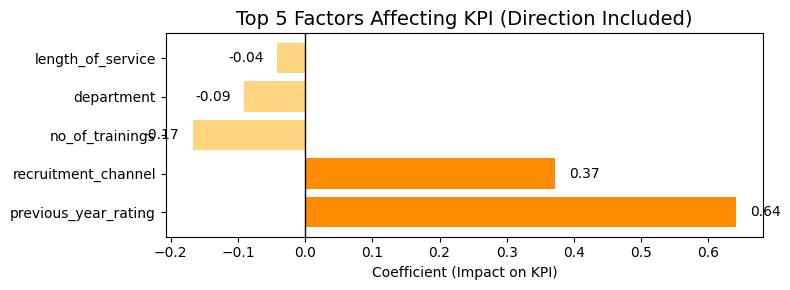

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Loại gender
plot_df = results_df[results_df['feature'] != 'gender']

# Lấy top 5 theo độ mạnh
top5_plot = plot_df.sort_values(by='importance', ascending=False).head(5)

# Màu theo dấu coef
colors = top5_plot['coef'].apply(lambda x: '#FF8C00' if x > 0 else '#FFD580')

plt.figure(figsize=(8,3))

bars = plt.barh(top5_plot['feature'], top5_plot['coef'], color=colors)

# Line 0 để phân biệt + và -
plt.axvline(0, color='black', linewidth=1)

plt.title("Top 5 Factors Affecting KPI (Direction Included)", fontsize=14)
plt.xlabel("Coefficient (Impact on KPI)")

# Hiển thị giá trị
for i, v in enumerate(top5_plot['coef']):
    plt.text(v + (0.02 if v > 0 else -0.02), i, f"{v:.2f}",
             va='center',
             ha='left' if v > 0 else 'right')

plt.tight_layout()
plt.show()